<a href="https://colab.research.google.com/github/futabarentarou/Rentarou-interacting-with-api-python-project-tutorial/blob/main/SOLUCION_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

sns.set_style("darkgrid")

BASE_URL = "https://api.worldbank.org/v2"
START_YEAR = 2010
END_YEAR = 2024

In [7]:
countries = {
    "ABW": "Aruba",
    "AFE": "Africa Eastern and Southern",
    "AFG": "Afghanistan",
    "AFR": "Africa",
    "AFW": "Africa Western and Central"
}

indicators = {
    "SP.POP.TOTL": "population_total",
    "NY.GDP.PCAP.CD": "gdp_per_capita",
    "SP.DYN.LE00.IN": "life_expectancy",
    "EN.ATM.CO2E.PC": "co2_per_capita"
}

In [8]:
def get_world_bank_data(country_code, indicator_code, start_year=2010, end_year=2024):
    """

    """
    url = f"{BASE_URL}/country/{country_code}/indicator/{indicator_code}"
    page = 1
    collected_rows = []

    while True:
        params = {
            "format": "json",
            "date": f"{start_year}:{end_year}",
            "page": page,
            "per_page": 100
        }

        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        data = response.json()

        if not data or len(data) < 2:
            break

        metadata = data[0]
        entries = data[1]

        if entries is None:
            break

        for item in entries:
            collected_rows.append({
                "country_code": country_code,
                "country": item["country"]["value"],
                "indicator_code": indicator_code,
                "year": item["date"],
                "value": item["value"]
            })

        if page >= int(metadata["pages"]):
            break

        page += 1

    return collected_rows

In [9]:
all_data = []

for country_code in countries.keys():
    for indicator_code in indicators.keys():
        rows = get_world_bank_data(
            country_code=country_code,
            indicator_code=indicator_code,
            start_year=START_YEAR,
            end_year=END_YEAR
        )
        all_data.extend(rows)

print(f"Total rows collected: {len(all_data)}")

Total rows collected: 180


In [10]:
df = pd.DataFrame(all_data)

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")

df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

df.head()

,country_code,country,indicator_code,year,value
0,ABW,Aruba,SP.POP.TOTL,2024,107995.0
1,ABW,Aruba,SP.POP.TOTL,2023,107359.0
2,ABW,Aruba,SP.POP.TOTL,2022,107310.0
3,ABW,Aruba,SP.POP.TOTL,2021,107700.0
4,ABW,Aruba,SP.POP.TOTL,2020,108587.0


In [11]:
indicator_tables = {}

for code, name in indicators.items():
    temp_df = df[df["indicator_code"] == code].copy()
    temp_df = temp_df.dropna(subset=["value"])
    temp_df = temp_df.sort_values(["country", "year"]).reset_index(drop=True)
    indicator_tables[name] = temp_df[["country", "year", "value"]]

indicator_tables["gdp_per_capita"].head()

,country,year,value
0,Afghanistan,2010,560.621505
1,Afghanistan,2011,606.694676
2,Afghanistan,2012,651.417134
3,Afghanistan,2013,637.087099
4,Afghanistan,2014,625.054942


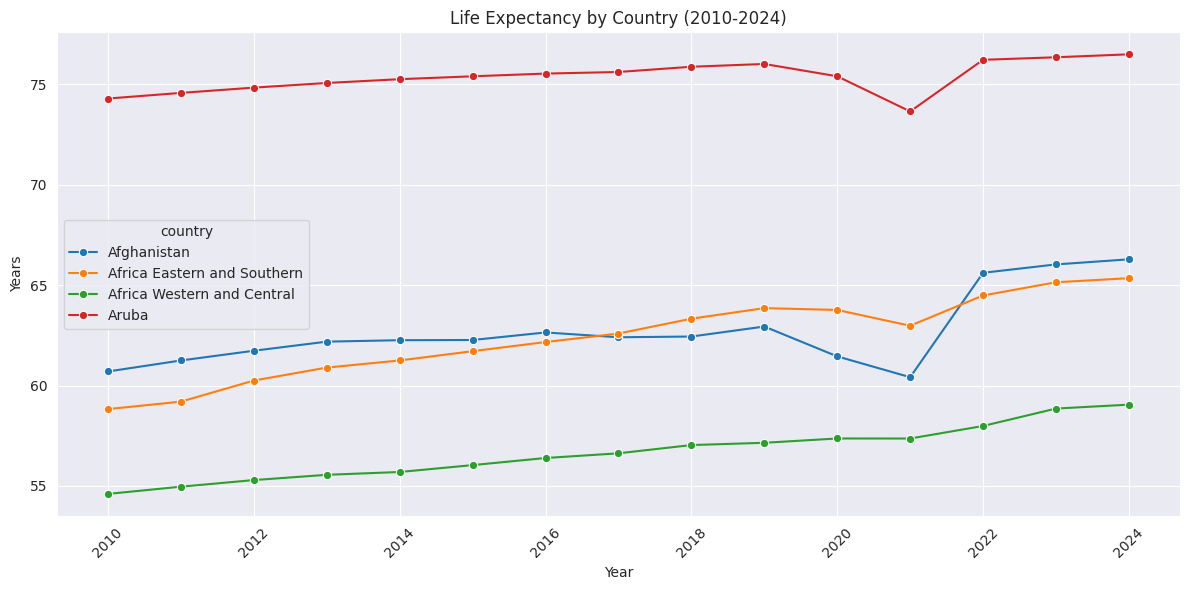

In [12]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=indicator_tables["life_expectancy"],
    x="year",
    y="value",
    hue="country",
    marker="o"
)

plt.title("Life Expectancy by Country (2010-2024)")
plt.xlabel("Year")
plt.ylabel("Years")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

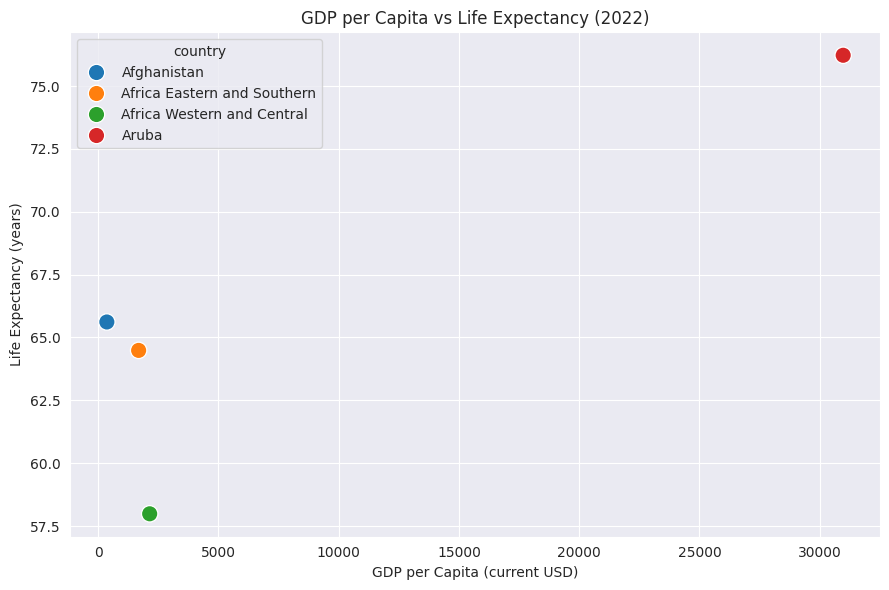

In [13]:
selected_year = 2022

gdp_2022 = indicator_tables["gdp_per_capita"]
gdp_2022 = gdp_2022[gdp_2022["year"] == selected_year].rename(columns={"value": "gdp_per_capita"})

life_2022 = indicator_tables["life_expectancy"]
life_2022 = life_2022[life_2022["year"] == selected_year].rename(columns={"value": "life_expectancy"})

comparison_df = pd.merge(
    gdp_2022[["country", "gdp_per_capita"]],
    life_2022[["country", "life_expectancy"]],
    on="country",
    how="inner"
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=comparison_df,
    x="gdp_per_capita",
    y="life_expectancy",
    hue="country",
    s=140
)

plt.title(f"GDP per Capita vs Life Expectancy ({selected_year})")
plt.xlabel("GDP per Capita (current USD)")
plt.ylabel("Life Expectancy (years)")
plt.tight_layout()
plt.show()

In [14]:
engine = create_engine("sqlite:///world_bank_analysis.db")

for table_name, table_df in indicator_tables.items():
    table_df.to_sql(table_name, con=engine, if_exists="replace", index=False)

print("Tables saved successfully.")

Tables saved successfully.


In [15]:
sample_query = "SELECT * FROM gdp_per_capita LIMIT 10"
sample_df = pd.read_sql(sample_query, engine)
sample_df

,country,year,value
0,Afghanistan,2010,560.621505
1,Afghanistan,2011,606.694676
2,Afghanistan,2012,651.417134
3,Afghanistan,2013,637.087099
4,Afghanistan,2014,625.054942
5,Afghanistan,2015,565.569730
6,Afghanistan,2016,522.082216
7,Afghanistan,2017,525.469771
8,Afghanistan,2018,491.337221
9,Afghanistan,2019,496.602504


In [ ]:
# La esperanza de vida presenta una tendencia general al alza en todos los casos analizados, aunque con diferencias claras entre regiones.

# Aruba se mantiene consistentemente como el territorio con mayor esperanza de vida (por encima de 74 años), mostrando estabilidad y niveles altos propios de economías más desarrolladas.

# Por otro lado, las regiones de África Occidental y Central presentan los valores más bajos, aunque con una mejora gradual a lo largo del tiempo.

# Afganistán muestra una evolución más inestable, con una caída notable alrededor de 2020–2021, seguida de una recuperación fuerte en los años posteriores.

# Este comportamiento sugiere que, aunque existe una tendencia global de mejora, los eventos externos (como crisis sanitarias o políticas) pueden impactar significativamente en algunos países.

In [ ]:
# Se observa una relación positiva entre el PIB per cápita y la esperanza de vida, aunque con ciertas diferencias estructurales entre regiones.

# Aruba destaca claramente como un outlier positivo, con un PIB per cápita muy alto (más de 30,000 USD) y una esperanza de vida superior a 76 años.

# Las regiones africanas presentan niveles más bajos tanto de ingreso como de esperanza de vida, especialmente África Occidental y Central.

# Afganistán se posiciona con un PIB per cápita muy bajo, pero con una esperanza de vida relativamente mayor a la de algunas regiones africanas, lo que indica que el ingreso no es el único factor determinante.

# En conjunto, el gráfico sugiere que existe una relación entre desarrollo económico y calidad de vida, pero también evidencia que esta relación no es completamente lineal.